In [2]:
import math

In [3]:
def dldx(x,y):
    return math.exp(x)

def dldy(x,y):
    return math.exp(y)
 


In [4]:
def L(x,y):
    # return ((y-2)**2)+((x+5)**2)
    return math.exp(x) + math.exp(y) 

In [5]:
x = -5
y = 1
eta = 0.05


In [6]:
init = 1000
L_values = []
# for _ in range(20):
while abs(L(x,y)-init) > 0.00001:  
    init = L(x,y)
    xnew = x - eta*dldx(x,y)
    ynew = y - eta*dldy(x,y)
    x = xnew
    y = ynew
    print(f"x: {x:.2f}, y: {y:.2f}, L(x,y): {L(x,y):.2f}")
    L_values.append(L(x,y))


x: -5.00, y: 0.86, L(x,y): 2.38
x: -5.00, y: 0.75, L(x,y): 2.11
x: -5.00, y: 0.64, L(x,y): 1.90
x: -5.00, y: 0.55, L(x,y): 1.73
x: -5.00, y: 0.46, L(x,y): 1.59
x: -5.00, y: 0.38, L(x,y): 1.47
x: -5.00, y: 0.31, L(x,y): 1.37
x: -5.00, y: 0.24, L(x,y): 1.28
x: -5.00, y: 0.18, L(x,y): 1.20
x: -5.00, y: 0.12, L(x,y): 1.13
x: -5.00, y: 0.06, L(x,y): 1.07
x: -5.00, y: 0.01, L(x,y): 1.01
x: -5.00, y: -0.04, L(x,y): 0.96
x: -5.00, y: -0.09, L(x,y): 0.92
x: -5.01, y: -0.14, L(x,y): 0.88
x: -5.01, y: -0.18, L(x,y): 0.84
x: -5.01, y: -0.22, L(x,y): 0.81
x: -5.01, y: -0.26, L(x,y): 0.78
x: -5.01, y: -0.30, L(x,y): 0.75
x: -5.01, y: -0.34, L(x,y): 0.72
x: -5.01, y: -0.37, L(x,y): 0.69
x: -5.01, y: -0.41, L(x,y): 0.67
x: -5.01, y: -0.44, L(x,y): 0.65
x: -5.01, y: -0.47, L(x,y): 0.63
x: -5.01, y: -0.50, L(x,y): 0.61
x: -5.01, y: -0.53, L(x,y): 0.59
x: -5.01, y: -0.56, L(x,y): 0.58
x: -5.01, y: -0.59, L(x,y): 0.56
x: -5.01, y: -0.62, L(x,y): 0.54
x: -5.01, y: -0.65, L(x,y): 0.53
x: -5.01, y: -0.67, L(

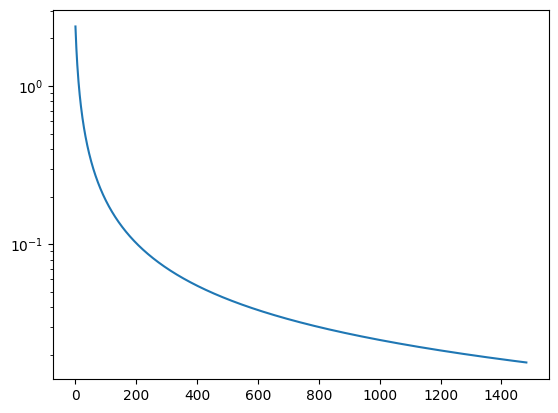

In [7]:
import matplotlib.pyplot as plt
plt.plot(L_values)
plt.yscale('log')

Text(0.5, 0, 'Iteration')

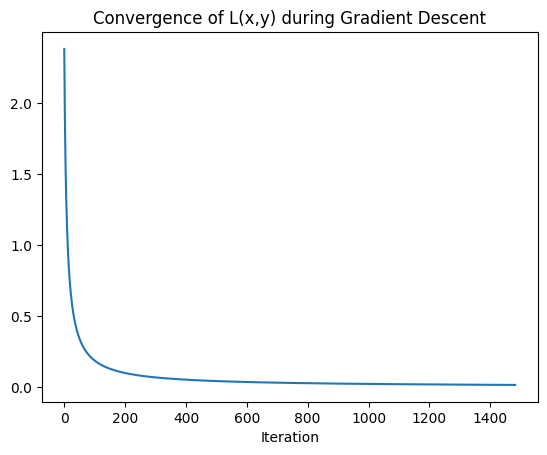

In [8]:
# the entire demo in one cell
import math
def L(x,y):
    return math.exp(x) + math.exp(y)
def dldx(x,y):
    return math.exp(x)
def dldy(x,y):
    return math.exp(y)

# Initialize parameters
x = -5
y = 1
# learning rate
eta = 0.05

# Store initial value of L
init = 1000
L_values = []

# Gradient descent loop
while abs(L(x,y)-init) > 0.00001: # iterate till convergence
    init = L(x,y)
    xnew = x - eta*dldx(x,y)
    ynew = y - eta*dldy(x,y)
    x = xnew
    y = ynew
    # print(f"x: {x:.2f}, y: {y:.2f}, L(x,y): {L(x,y):.2f}")
    L_values.append(L(x,y))
# Plotting the values of L over iterations

import matplotlib.pyplot as plt
plt.plot(L_values)
plt.title('Convergence of L(x,y) during Gradient Descent')
plt.xlabel('Iteration')

# plt.yscale('log')


Text(0.5, 1.0, 'Convergence of L(x,y) during Gradient Descent (PyTorch)')

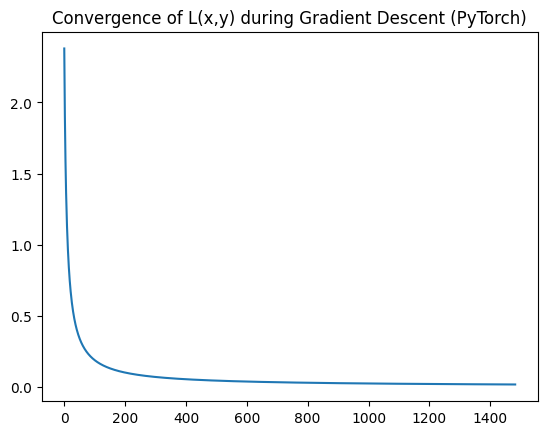

In [9]:
# the full thing but in pytorch
import torch

# Define the function L(x, y)

def L_torch(x, y):
    return torch.exp(x) + torch.exp(y)

# Initialize parameters
x = torch.tensor(-5.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)

# Define the learning rate
eta = 0.05

# Store initial value of L
init = 1000

L_values = []

# Gradient descent loop
while abs(L_torch(x, y).item() - init) > 0.00001:  # iterate till convergence
    init = L_torch(x, y).item()
    L_torch(x, y).backward()
    with torch.no_grad():
        x -= eta * x.grad
        y -= eta * y.grad
        x.grad.zero_()
        y.grad.zero_()
    L_values.append(L_torch(x, y).item())
    # print(f"x: {x.item():.2f}, y: {y.item():.2f}, L(x,y): {L_torch(x, y).item():.2f}")

plt.plot(L_values)
plt.title('Convergence of L(x,y) during Gradient Descent (PyTorch)')

Text(0.5, 1.0, 'Convergence of L(x,y) during Gradient Descent (PyTorch SGD)')

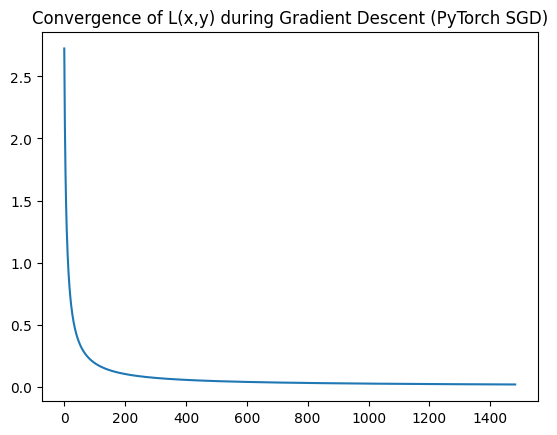

In [10]:
# use pytorch sgd for the above

import torch
import torch.optim as optim

# Define the function L(x, y)
def L_torch(x, y):
    return torch.exp(x) + torch.exp(y)

# Initialize parameters
x = torch.tensor(-5.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)
# Define the learning rate
eta = 0.05

# Create an optimizer
optimizer = optim.SGD([x, y], lr=eta)

# Store initial value of L
init = 1000
L_values = []
# Gradient descent loop
while abs(L_torch(x, y).item() - init) > 0.00001:  # iterate till convergence
    init = L_torch(x, y).item()
    optimizer.zero_grad()  # Clear gradients
    loss = L_torch(x, y)  # Compute the loss
    loss.backward()  # Backpropagate to compute gradients
    optimizer.step()  # Update parameters
    L_values.append(loss.item())
    # print(f"x: {x.item():.2f}, y: {y.item():.2f}, L(x,y): {loss.item():.2f}")

plt.plot(L_values)
plt.title('Convergence of L(x,y) during Gradient Descent (PyTorch SGD)')

Text(0.5, 1.0, 'Convergence of L(X) during Gradient Descent (PyTorch Class)')

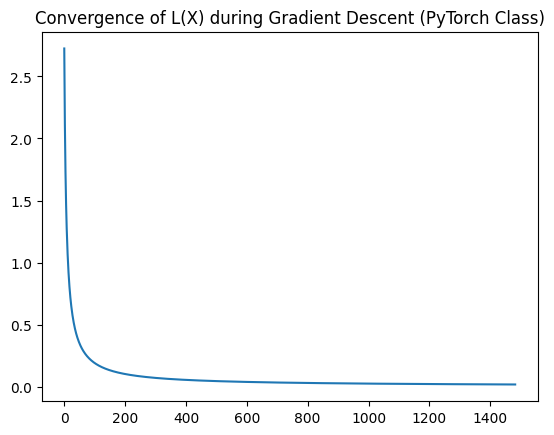

In [11]:
# idiomatic pytorch code for the above, with a class. x and y can be X, a vector of parameters, 
# and L can be a more complex function. This is just a template to show how to structure the code.

import torch

class GradientDescentOptimizer:
    def __init__(self, parameters, learning_rate):
        self.parameters = parameters
        self.learning_rate = learning_rate
        self.optimizer = torch.optim.SGD(self.parameters, lr=self.learning_rate)

    def step(self, loss):
        self.optimizer.zero_grad()  # Clear gradients
        loss.backward()  # Backpropagate to compute gradients
        self.optimizer.step()  # Update parameters

def L_torch(X):
    return torch.exp(X[0]) + torch.exp(X[1])

# Initialize parameters
X = torch.tensor([-5.0, 1.0], requires_grad=True)
# Define the learning rate
eta = 0.05

# Create an optimizer instance
optimizer = GradientDescentOptimizer([X], learning_rate=eta)
# Store initial value of L
init = 1000
L_values = []
# Gradient descent loop
while abs(L_torch(X).item() - init) > 0.00001:
    init = L_torch(X).item()
    loss = L_torch(X)  # Compute the loss
    optimizer.step(loss)  # Perform an optimization step
    L_values.append(loss.item())
    # print(f"X: {X.detach().numpy()}, L(X): {loss.item():.2f}")
plt.plot(L_values)
plt.title('Convergence of L(X) during Gradient Descent (PyTorch Class)')


In [12]:
# fit a linear regression model using pytorch
# inputs
X = torch.tensor([[1.0], [2.0], [3.0], [4.0], [5.0]])  # 5 samples, 1 feature
y = torch.tensor([[3.0], [5.0], [7.0], [9.0], [11.0]])  # 5 samples, 1 target

class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # 1 input feature, 1 output

    def forward(self, x):
        return self.linear(x)
# Create model instance
model = LinearRegressionModel()
# Define loss function and optimizer
criterion = torch.nn.MSELoss()  # Mean Squared Error Loss
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
# Training loop
num_epochs = 10000
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()  # Clear gradients
    outputs = model(X)  # Forward pass
    loss = criterion(outputs, y)  # Compute loss
    loss.backward()  # Backpropagate to compute gradients
    optimizer.step()  # Update parameters
    if (epoch) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
    if loss.item() < 0.00001:
        print(f'Converged at epoch {epoch+1}')
        break

Epoch [1/10000], Loss: 95.4003
Epoch [11/10000], Loss: 0.4350
Epoch [21/10000], Loss: 0.0058
Epoch [31/10000], Loss: 0.0036
Epoch [41/10000], Loss: 0.0034
Epoch [51/10000], Loss: 0.0032
Epoch [61/10000], Loss: 0.0030
Epoch [71/10000], Loss: 0.0028
Epoch [81/10000], Loss: 0.0026
Epoch [91/10000], Loss: 0.0024
Epoch [101/10000], Loss: 0.0023
Epoch [111/10000], Loss: 0.0021
Epoch [121/10000], Loss: 0.0020
Epoch [131/10000], Loss: 0.0018
Epoch [141/10000], Loss: 0.0017
Epoch [151/10000], Loss: 0.0016
Epoch [161/10000], Loss: 0.0015
Epoch [171/10000], Loss: 0.0014
Epoch [181/10000], Loss: 0.0013
Epoch [191/10000], Loss: 0.0012
Epoch [201/10000], Loss: 0.0011
Epoch [211/10000], Loss: 0.0011
Epoch [221/10000], Loss: 0.0010
Epoch [231/10000], Loss: 0.0009
Epoch [241/10000], Loss: 0.0009
Epoch [251/10000], Loss: 0.0008
Epoch [261/10000], Loss: 0.0008
Epoch [271/10000], Loss: 0.0007
Epoch [281/10000], Loss: 0.0007
Epoch [291/10000], Loss: 0.0006
Epoch [301/10000], Loss: 0.0006
Epoch [311/10000],

In [13]:
# values of model parameters
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.data.numpy()}")

linear.weight: [[1.9979546]]
linear.bias: [1.0073845]


In [39]:
import torch
# fit a linear regression model using pytorch
# inputs
X = torch.tensor([[1.0, 2.0], [2.0, 3.0], [3.0, 4.0], [4.0, 5.0], [5.0, 6.0], [10.0, 20.0]])  # 6 samples, 2 features
y = torch.tensor([[5.0], [8.0], [11.0], [14.0], [17.0], [50.0]])  # 6 samples, 1 target

class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(2, 1, bias=True)  # 2 input features, 1 output

    def forward(self, x):
        return self.linear(x)
# Create model instance
model = LinearRegressionModel()
# Define loss function and optimizer
criterion = torch.nn.MSELoss()  # Mean Squared Error Loss
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
# Training loop
num_epochs = 10000
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()  # Clear gradients
    outputs = model(X)  # Forward pass
    loss = criterion(outputs, y)  # Compute loss
    loss.backward()  # Backpropagate to compute gradients
    if (epoch) % 100 == 0:
        print(model.linear.weight.grad.norm())
        print(model.linear.bias.grad.norm())
    optimizer.step()  # Update parameters
    if (epoch) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
    if loss.item() < 0.00001:
        print(f'Converged at epoch {epoch+1}')
        break

tensor(481.4665)
tensor(35.9664)
Epoch [1/10000], Loss: 543.2772
tensor(0.3322)
tensor(0.3366)
Epoch [101/10000], Loss: 0.0679
tensor(0.2605)
tensor(0.2870)
Epoch [201/10000], Loss: 0.0494
tensor(0.2027)
tensor(0.2464)
Epoch [301/10000], Loss: 0.0370
tensor(0.1561)
tensor(0.2130)
Epoch [401/10000], Loss: 0.0285
tensor(0.1186)
tensor(0.1855)
Epoch [501/10000], Loss: 0.0227
tensor(0.0885)
tensor(0.1627)
Epoch [601/10000], Loss: 0.0186
tensor(0.0644)
tensor(0.1439)
Epoch [701/10000], Loss: 0.0156
tensor(0.0451)
tensor(0.1282)
Epoch [801/10000], Loss: 0.0135
tensor(0.0299)
tensor(0.1152)
Epoch [901/10000], Loss: 0.0119
tensor(0.0181)
tensor(0.1042)
Epoch [1001/10000], Loss: 0.0106
tensor(0.0096)
tensor(0.0949)
Epoch [1101/10000], Loss: 0.0096
tensor(0.0065)
tensor(0.0871)
Epoch [1201/10000], Loss: 0.0088
tensor(0.0093)
tensor(0.0804)
Epoch [1301/10000], Loss: 0.0081
tensor(0.0130)
tensor(0.0746)
Epoch [1401/10000], Loss: 0.0074
tensor(0.0162)
tensor(0.0697)
Epoch [1501/10000], Loss: 0.0069

In [35]:
# values of model parameters
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.data.numpy()}")

linear.weight: [[0.99613976 2.001599  ]]
linear.bias: [0.00651153]


In [37]:
# calculate the value for a given x and y using the trained model
x_input = torch.tensor([[60.0, 7.0]])  # New input
model.eval()  # Set the model to evaluation mode
model_output = model(x_input)  # Get the model's prediction
print(f"Model output for input {x_input.numpy()}: {model_output.detach().numpy()}")

Model output for input [[60.  7.]]: [[73.78609]]


In [30]:
# implement linear regression using pytorch's autograd and SGD optimizer, 
# without using torch.nn.Linear or torch.nn.Module

import torch
from torch import optim

X = torch.tensor([[1.0, 2.0], [2.0, 3.0], [3.0, 4.0], [4.0, 5.0], [5.0, 6.0], [6.0, 7.0], [10.0, 20.0]])  # 7 samples, 2 features
y = torch.tensor([[5.0], [8.0], [11.0], [14.0], [17.0], [20.0], [50.0]])  # 7 samples, 1 target

class LinearRegression:
    def __init__(self):
        self.weights = torch.randn(2, 1, requires_grad=True)  # 2 input features, 1 output
        self.bias = torch.randn(1, requires_grad=True)  # Bias term

    def predict(self, x):
        return x @ self.weights + self.bias  # Linear prediction
    
model = LinearRegression()
criterion = torch.nn.MSELoss()  # Mean Squared Error Loss
optimizer = optim.SGD([model.weights, model.bias], lr=0.001)
num_epochs = 10000
for epoch in range(num_epochs):
    optimizer.zero_grad()  # Clear gradients
    outputs = model.predict(X)  # Forward pass
    loss = criterion(outputs, y)  # Compute loss
    loss.backward()  # Backpropagate to compute gradients
    optimizer.step()  # Update parameters
    if (epoch) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f} parameters: {model.weights.data.numpy()} {model.bias.data.numpy()}')
    if loss.item() < 0.00001:
        print(f'Converged at epoch {epoch+1}')
        break
print(f"Weights: {model.weights.data.numpy()} Bias: {model.bias.data.numpy()}")


Epoch [1/10000], Loss: 511.4326 parameters: [[-0.4799068 ]
 [ 0.77500296]] [0.5407159]
Epoch [101/10000], Loss: 0.2136 parameters: [[0.47681534]
 [2.2460246 ]] [0.6782468]
Epoch [201/10000], Loss: 0.1723 parameters: [[0.5320438]
 [2.2140355]] [0.67305255]
Epoch [301/10000], Loss: 0.1445 parameters: [[0.5769706]
 [2.1884854]] [0.66362226]
Epoch [401/10000], Loss: 0.1250 parameters: [[0.61386824]
 [2.167932  ]] [0.6511211]
Epoch [501/10000], Loss: 0.1106 parameters: [[0.6444924]
 [2.1512637]] [0.6364407]
Epoch [601/10000], Loss: 0.0995 parameters: [[0.67019767]
 [2.1376226 ]] [0.62026155]
Epoch [701/10000], Loss: 0.0904 parameters: [[0.6920364]
 [2.1263418]] [0.6031028]
Epoch [801/10000], Loss: 0.0829 parameters: [[0.7108181]
 [2.1169116]] [0.58535725]
Epoch [901/10000], Loss: 0.0763 parameters: [[0.72717255]
 [2.1089342 ]] [0.56732213]
Epoch [1001/10000], Loss: 0.0705 parameters: [[0.74158794]
 [2.102102  ]] [0.54922175]
Epoch [1101/10000], Loss: 0.0652 parameters: [[0.75444186]
 [2.096

In [58]:
import torch
from torch import optim

X = torch.randn(100, 2)  # 100 samples, 2 features
y = 2 * X[:, 0] ** 2 + 3 * X[:, 1] ** 3
y = y.view(-1, 1)  # Reshape to (100, 1)

class fcn(torch.nn.Module):
    def __init__(self):
        super(fcn, self).__init__()
        self.linear1 = torch.nn.Linear(2, 16)  # 2 input features, 16 outputs
        self.tanh = torch.nn.Tanh()  # Activation function
        self.linear2 = torch.nn.Linear(16, 16)  # 16 inputs from previous layer, 16 outputs
        self.linear3 = torch.nn.Linear(16, 1)  # 16 inputs from previous layer, 1 output
        
    def forward(self, x):
        x = self.linear1(x)
        x = self.tanh(x)
        x = self.linear2(x)
        x = self.tanh(x)
        x = self.linear3(x)
        return x
    

model = fcn()
criterion = torch.nn.MSELoss()  # Mean Squared Error Loss
optimizer = optim.SGD(model.parameters(), lr=0.001)

num_epochs = 100000
for epoch in range(num_epochs):
    optimizer.zero_grad()  # Clear gradients
    outputs = model(X)  # Forward pass
    loss = criterion(outputs, y)  # Compute loss
    loss.backward()  # Backpropagate to compute gradients
    optimizer.step()  # Update parameters
    if (epoch) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
        model.eval()
        model_output = model(X[0:1])  # Get the model's prediction for the first sample
        print(f"Model output for first sample: {model_output.detach().numpy()}, Actual value: {y[0:1].numpy()}")
    







Epoch [1/100000], Loss: 271.6430
Model output for first sample: [[-0.02003954]], Actual value: [[2.2042232]]
Epoch [1001/100000], Loss: 43.1264
Model output for first sample: [[3.2026868]], Actual value: [[2.2042232]]
Epoch [2001/100000], Loss: 18.8839
Model output for first sample: [[2.6945796]], Actual value: [[2.2042232]]
Epoch [3001/100000], Loss: 9.8343
Model output for first sample: [[2.5027587]], Actual value: [[2.2042232]]
Epoch [4001/100000], Loss: 5.0688
Model output for first sample: [[2.4459066]], Actual value: [[2.2042232]]
Epoch [5001/100000], Loss: 2.6102
Model output for first sample: [[2.4193294]], Actual value: [[2.2042232]]
Epoch [6001/100000], Loss: 1.3496
Model output for first sample: [[2.3922503]], Actual value: [[2.2042232]]
Epoch [7001/100000], Loss: 0.7028
Model output for first sample: [[2.3584125]], Actual value: [[2.2042232]]
Epoch [8001/100000], Loss: 0.3688
Model output for first sample: [[2.318933]], Actual value: [[2.2042232]]
Epoch [9001/100000], Loss:

In [59]:
model.eval()
model(torch.tensor([1.0, 1.0], dtype=torch.float32))

tensor([4.9658], grad_fn=<ViewBackward0>)

In [57]:
2+3


5

In [5]:
import torch
from torch import optim

# sample CNN

class Alexnet(torch.nn.Module):
    def __init__(self):
        super(Alexnet, self).__init__()
        self.conv1 = torch.nn.Conv2d(3, 96, kernel_size=11, stride=4) # input dim = (3, 227, 227), output dim = (96, 55, 55)
        self.relu1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(kernel_size=3, stride=2)
        self.conv2 = torch.nn.Conv2d(96, 256, kernel_size=5, padding=2) # input dim = (96, 27, 27), output dim = (256, 27, 27)
        self.relu2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(kernel_size=3, stride=2) # input dim = (256, 27, 27), output dim = (256, 13, 13)
        self.conv3 = torch.nn.Conv2d(256, 384, kernel_size=3, padding=1) # input dim = (256, 13, 13), output dim = (384, 13, 13)
        self.relu3 = torch.nn.ReLU()
        self.conv4 = torch.nn.Conv2d(384, 384, kernel_size=3, padding=1) # input dim = (384, 13, 13), output dim = (384, 13, 13)
        self.relu4 = torch.nn.ReLU()
        self.conv5 = torch.nn.Conv2d(384, 256, kernel_size=3, padding=1) # input dim = (384, 13, 13), output dim = (256, 13, 13)
        self.relu5 = torch.nn.ReLU()
        # self.pool5 = torch.nn.MaxPool2d(kernel_size=3, stride=2) # input dim = (256, 13, 13), output dim = (256, 6, 6)
        self.pool5 = torch.nn.AdaptiveAvgPool2d((6, 6))  # input dim = (256, 13, 13), output dim = (256, 6, 6)
        self.fc6 = torch.nn.Linear(256 * 6 * 6, 4096)
        self.relu6 = torch.nn.ReLU()
        self.fc7 = torch.nn.Linear(4096, 4096)
        self.relu7 = torch.nn.ReLU()
        self.fc8 = torch.nn.Linear(4096, 1000)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.conv4(x)
        x = self.relu4(x)
        x = self.conv5(x)
        x = self.relu5(x)
        x = self.pool5(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.fc6(x)
        x = self.relu6(x)
        x = self.fc7(x)
        x = self.relu7(x)
        x = self.fc8(x)
        return x
    

model = Alexnet()
# number of parameters in the model
num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters in the model: {num_params}")



Number of parameters in the model: 62378344


In [6]:
# model summary
print(model)

Alexnet(
  (conv1): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (conv4): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu4): ReLU()
  (conv5): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu5): ReLU()
  (pool5): AdaptiveAvgPool2d(output_size=(6, 6))
  (fc6): Linear(in_features=9216, out_features=4096, bias=True)
  (relu6): ReLU()
  (fc7): Linear(in_features=4096, out_features=4096, bias=True)
  (relu7): ReLU()
  (fc8): Linear(in_features=4096, out_features=1000, bias=True)
)


In [8]:
# load data and labels
# folder d:\examples

X = torch.randn(100, 3, 224, 224)  # 100 samples, 3 channels, 224x224 images
y = torch.randint(0, 1000, (100,))  # 100 samples, random labels between 0 and 999

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

# training loop

epochs = 10
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [1/10], Loss: 6.9072
Epoch [2/10], Loss: 6.9070


KeyboardInterrupt: 

In [ ]:
# classic resnet

import torch
from torch import nn, optim

class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResNetBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        if in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.downsample = None

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(identity)
        out += identity
        out = self.relu(out)
        return out
    
class ResNet(nn.Module):
    def __init__(self, num_classes=1000):
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        layers = []
        layers.append(ResNetBlock(in_channels, out_channels))
        for _ in range(1, blocks):
            layers.append(ResNetBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)  # Flatten the tensor
        x = self.fc(x)
        return x
    
